In [53]:
# Import necessary libraries
import os
import sys
# Add the utils folder to the system path so we can import custom modules
sys.path.append(os.path.abspath("utils"))
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import pandas as pd
from utils.reproducibility_utils import seed_everything
from utils.data_loading import load_data, load_test_data, feature_names

# Set the plotting style for better-looking visualizations
plt.style.available
plt.style.use('seaborn-v0_8')
from utils.kaggle_metric import score


In [54]:
# Set random seed for reproducibility across runs
# This ensures that your results will be the same every time you run the notebook
seed_everything(42)  # for reproducibility

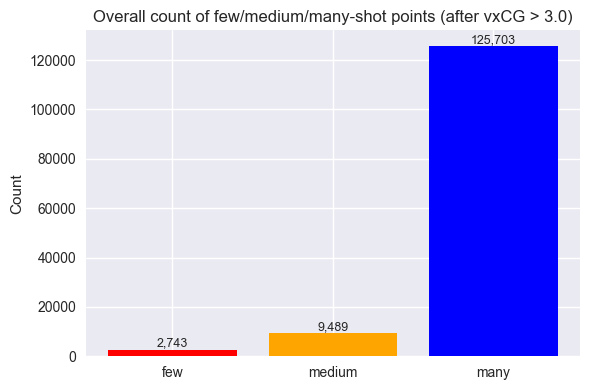

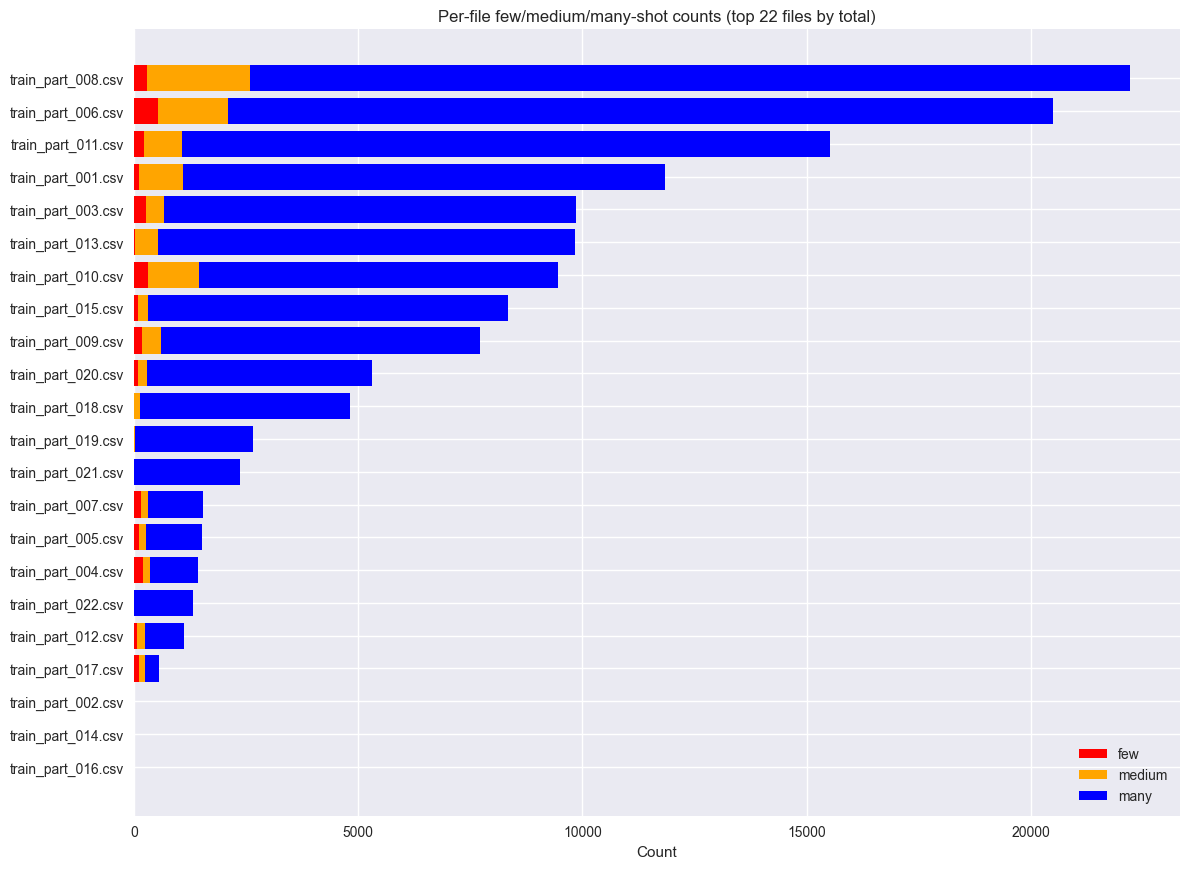

Per-file summary (top rows):


,few,medium,many,unknown,total
file,,,,,
train_part_008.csv,281,2308,19631,0,22220
train_part_006.csv,526,1563,18417,0,20506
train_part_011.csv,230,829,14460,0,15519
train_part_001.csv,117,971,10753,0,11841
train_part_003.csv,271,402,9195,0,9868
train_part_013.csv,15,516,9301,0,9832
train_part_010.csv,301,1157,8000,0,9458
train_part_015.csv,84,223,8040,0,8347
train_part_009.csv,177,412,7130,0,7719



Overall counts:
few          2743
medium       9489
many       125703
unknown         0
dtype: int64


In [55]:
# Plot counts of few/medium/many-shot points in training CSVs
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Paths
train_base_dir = "datasets_challenge/train"
# Try to resolve the distribution CSV robustly
dist_csv_candidates = [
    os.path.abspath(os.path.join("..", "sideSlip_distribution.csv")),  # parent of 20251118
    "sideSlip_distribution.csv",
    "E:/TH_koeln_AIT/Courses/sem_3/VSA_DIR/Code/sideSlip_distribution.csv",  # known absolute used before
]
dist_csv = next((p for p in dist_csv_candidates if os.path.exists(p)), None)
if dist_csv is None:
    raise FileNotFoundError("sideSlip_distribution.csv not found. Update dist_csv_candidates to your path.")

# 2) Shot band mapping from the distribution CSV (rounded to 0.1)
dist_df = pd.read_csv(dist_csv)
shot_band_mapping = dist_df.groupby("sideSlip")["band"].first()  # sideSlip (rounded to 0.1) -> band

# 3) Helper to scan CSVs
def list_csvs(base_dir):
    csvs = []
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.endswith(".csv"):
                csvs.append(os.path.join(root, f))
    return sorted(csvs)

def load_and_label(filepath, vx_threshold=3.0):
    df = pd.read_csv(filepath)
    # Apply the same speed threshold as training
    if "vxCG" in df.columns:
        df = df[df["vxCG"] > vx_threshold]
    # Assign band per row from rounded sideSlip
    if "sideSlip" not in df.columns:
        df["band"] = "unknown"
    else:
        df["band"] = df["sideSlip"].round(1).map(shot_band_mapping).fillna("unknown")
    return df

# 4) Aggregate counts overall and per file
files = list_csvs(train_base_dir)
per_file_counts = []
overall_counts = {"few": 0, "medium": 0, "many": 0, "unknown": 0}

for fp in files:
    df = load_and_label(fp, vx_threshold=3.0)
    vc = df["band"].value_counts()
    row = {
        "file": os.path.relpath(fp, train_base_dir),
        "few": int(vc.get("few", 0)),
        "medium": int(vc.get("medium", 0)),
        "many": int(vc.get("many", 0)),
        "unknown": int(vc.get("unknown", 0)),
    }
    per_file_counts.append(row)
    for k in overall_counts:
        overall_counts[k] += row[k]

per_file_df = pd.DataFrame(per_file_counts).set_index("file")
per_file_df = per_file_df[["few", "medium", "many", "unknown"]]

# 5) Overall bar plot (few/medium/many)
cats = ["few", "medium", "many"]
counts = [overall_counts[c] for c in cats]

plt.figure(figsize=(6, 4))
colors = {"few": "red", "medium": "orange", "many": "blue"}
plt.bar(cats, counts, color=[colors[c] for c in cats])
plt.title("Overall count of few/medium/many-shot points (after vxCG > 3.0)")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# 6) Per-file stacked bar (top 15 by total count)
topN = 22
plot_cols = ["few", "medium", "many"]  # ignore 'unknown' for clarity
top_df = per_file_df.assign(total=per_file_df[plot_cols].sum(axis=1)).sort_values("total", ascending=False).head(topN)

plt.figure(figsize=(12, max(5, 0.4 * len(top_df))))
bottom = np.zeros(len(top_df))
for c in plot_cols:
    plt.barh(top_df.index, top_df[c].values, left=bottom, color=colors[c], label=c)
    bottom += top_df[c].values

plt.title(f"Per-file few/medium/many-shot counts (top {topN} files by total)")
plt.xlabel("Count")
plt.legend(loc="lower right")
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

# 7) Print a small summary table (optional)
display_cols = plot_cols + ["unknown", "total"]
print("Per-file summary (top rows):")
display(top_df[display_cols].head(22))
print("\nOverall counts:")
print(pd.Series(overall_counts)[["few", "medium", "many", "unknown"]])

In [56]:
print("Loading train data...")
train_dataloader, val_dataloader, pipeline = load_data(
    train_path = "datasets_challenge/train",  # Path to training data
    train_ratio = 0.8,  # Use 80% for training, 20% for validation
    batchsize = 512,  # Number of samples per batch
    # columns_to_standardize = feature_names,  # Option to specify which columns to standardize
    columns_to_drop = ["sideSlip", "vyCG", "time", "longitude","latitude"],  # Remove these from features
    sequence_length = 20,  # Number of time steps in each sequence (t-19 to t0)
    threshold = True,  # Enable velocity thresholding
    threshold_value = 3.0,  # Only keep samples where vehicle speed > 3 m/s
    threshold_column = "vxCG",  # Column to apply threshold on (longitudinal velocity)
    target = "sideSlip",  # The variable we want to predict
    scaling = True,  # Apply standardization to features
    seed = 42,  # Random seed for train/val split
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Loading train data...
datasets_challenge/train\train_part_001.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_012.csv
datasets_c

In [57]:
import torch
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Applying label density based on binning + Gaussian smoothing
def apply_label_density(datasets, num_bins, sigma=2):
    """
    Compute smoothed label densities for regression targets using binning + Gaussian smoothing.

    Args:
        datasets: list of datasets, each with attribute .y
        num_bins: number of bins for discretizing target space
        sigma: standard deviation for Gaussian smoothing

    Returns:
        densities: tensor of smoothed densities for all targets
    """
    # 1. Collect all targets into one tensor
    all_targets = torch.cat([
        d.y if isinstance(d.y, torch.Tensor) else torch.as_tensor(d.y)
        for d in datasets
    ], dim=0)
    print(f"Total number of targets: {len(all_targets)}")

    # 2. Create bins over the target range
    y_min, y_max = all_targets.min().item(), all_targets.max().item()
    bins = torch.linspace(y_min, y_max, num_bins)

    # 3. Compute histogram (count targets in each bin)
    hist = torch.histc(all_targets.float(), bins=num_bins, min=y_min, max=y_max)

    # 4. Smooth histogram with Gaussian filter
    smoothed = gaussian_filter1d(hist.numpy(), sigma=sigma)

    # 5. Interpolate densities back to original targets
    densities = np.interp(all_targets.numpy(), bins.numpy(), smoothed)

    # 6. Normalize densities to [0, 1]
    densities = (densities - densities.min()) / (densities.max() - densities.min())
    densities = torch.tensor(densities, dtype=torch.float32)
    print(f"Densities shape: {densities.shape}")

    # 7. Assign densities back to individual datasets
    start = 0
    for d in datasets:
        n = len(d.y)
        d.densities = densities[start:start + n]
        start += n
        print(f"Assigned densities to dataset with {n} samples.")

    return densities

# Applying label density to training set
densities = apply_label_density(train_dataloader.dataset.dataset.datasets, num_bins=6000, sigma=2)
# loading the densities for validation set as well
#densities_val = apply_label_density(val_dataloader.dataset, num_bins=2000, sigma=2)


Total number of targets: 137920
Densities shape: torch.Size([137920])
Assigned densities to dataset with 11841 samples.
Assigned densities to dataset with 88 samples.
Assigned densities to dataset with 767 samples.
Assigned densities to dataset with 329 samples.
Assigned densities to dataset with 8684 samples.
Assigned densities to dataset with 799 samples.
Assigned densities to dataset with 482 samples.
Assigned densities to dataset with 149 samples.
Assigned densities to dataset with 1201 samples.
Assigned densities to dataset with 324 samples.
Assigned densities to dataset with 19721 samples.
Assigned densities to dataset with 377 samples.
Assigned densities to dataset with 174 samples.
Assigned densities to dataset with 234 samples.
Assigned densities to dataset with 96 samples.
Assigned densities to dataset with 984 samples.
Assigned densities to dataset with 407 samples.
Assigned densities to dataset with 47 samples.
Assigned densities to dataset with 22220 samples.
Assigned dens

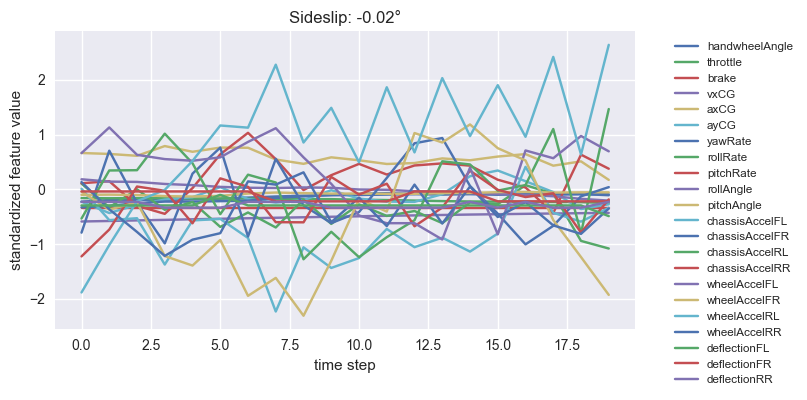

In [58]:
# Get one batch of data from the training dataloader
X, y, d= next(iter(train_dataloader))

# Visualize the first sample in the batch
plt.figure(figsize=(8,4))
plt.plot(X[0,:,:], label=feature_names)  # Plot all 22 features over 20 time steps
plt.title("Sideslip: "+str(round(y[0].item(),2))+"°")  # Show the target value
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.xlabel("time step")
plt.ylabel("standardized feature value")
plt.show()

## Safe ensemble

In [8]:
import torch, numpy as np

def safe_ensemble(models, val_dataloader, device='cuda', use_uncertainty=True,
                  n_mc=15, mode='softmax_uncert', alpha=5.0, min_unc=1e-3, max_overweight=0.95):
    """
    mode: 'mean', 'median', 'softmax_uncert', 'inv_uncert_clipped'
    returns: ensemble_preds (torch on cpu), truths (torch on cpu), debug dict
    """
    n_models = len(models)
    preds_per_model = [ [] for _ in range(n_models) ]
    uncerts_per_model = [ [] for _ in range(n_models) ]
    truths_list = []
    
    # ensure val_dataloader has shuffle=False to keep consistent ordering
    for batch in val_dataloader:
        if len(batch) == 3:
            bx, by, _ = batch
        else:
            bx, by = batch
        bx = bx.to(device)
        by = by.to(device)
        truths_list.append(by.detach().cpu())
        
        for i, model in enumerate(models):
            model.to(device)
            if use_uncertainty:
                model.train()  # MC dropout
                mc_preds = []
                with torch.no_grad():
                    for _ in range(n_mc):
                        p = model(bx).detach().cpu()
                        mc_preds.append(p.numpy())
                mc_preds = np.array(mc_preds)  # [n_mc, batch]
                mean = torch.tensor(mc_preds.mean(axis=0))
                std = torch.tensor(mc_preds.std(axis=0))
                preds_per_model[i].append(mean)
                uncerts_per_model[i].append(std)
            else:
                model.eval()
                with torch.no_grad():
                    p = model(bx).detach().cpu()
                preds_per_model[i].append(p)
                uncerts_per_model[i].append(torch.ones_like(p) * min_unc)

    # concat
    all_preds = torch.stack([torch.cat(preds_per_model[i], dim=0) for i in range(n_models)], dim=0)  # [n_models, n_samples]
    all_unc = torch.stack([torch.cat(uncerts_per_model[i], dim=0) for i in range(n_models)], dim=0)
    truths = torch.cat(truths_list, dim=0)
    
    debug = {'all_preds_mean_per_model': all_preds.mean(dim=1).cpu().numpy(),
             'all_unc_mean_per_model': all_unc.mean(dim=1).cpu().numpy()}
    
    # choose aggregation
    if mode == 'mean':
        ens = all_preds.mean(dim=0)
    elif mode == 'median':
        ens = torch.median(all_preds, dim=0).values
    elif mode == 'softmax_uncert':
        # clamp uncertainties for safety
        u = torch.clamp(all_unc, min=min_unc)
        weights = torch.softmax(-alpha * u, dim=0)  # softmax across models per sample
        max_w = weights.max(dim=0).values
        debug['max_weight_per_sample'] = max_w.cpu().numpy()
        if (max_w > max_overweight).any():
            debug['fallback'] = 'median due to overweighted model'
            ens = torch.median(all_preds, dim=0).values
        else:
            ens = (weights * all_preds).sum(dim=0)
    elif mode == 'inv_uncert_clipped':
        u = torch.clamp(all_unc, min=min_unc)
        w = 1.0 / (u + 1e-12)
        w = w / w.sum(dim=0, keepdim=True)
        max_w = w.max(dim=0).values
        debug['max_weight_per_sample'] = max_w.cpu().numpy()
        if (max_w > max_overweight).any():
            debug['fallback'] = 'mean due to overweighted model'
            ens = all_preds.mean(dim=0)
        else:
            ens = (w * all_preds).sum(dim=0)
    else:
        raise ValueError("Unknown mode")
    
    # final sanity clip to label range
    # optional: adapt min_label/max_label if known
    ens = torch.clamp(ens, min=-1e6, max=1e6)
    return ens, truths, debug





## GRU + early stopping

In [67]:
class GRUfew(nn.Module):
    """
    A more stable GRU regressor designed for imbalanced regression tasks.
    Removes BatchNorm, improves regularization,
    and integrates FDS in a controlled way.
    """

    def __init__(
        self,
        input_dim,
        hidden_size=64,
        output_dim=1,
        dropout=0.15,
        use_fds=False,
        layer_norm=True,
        fds_warmup_epochs=5,
    ):
        super().__init__()

        self.use_fds = use_fds
        self.fds_warmup_epochs = fds_warmup_epochs


        # ============================
        # 1. GRU Backbone
        # ============================
        self.gru = nn.GRU(
            input_dim,
            hidden_size,
            num_layers=3,
            dropout=0.3,
            batch_first=True,
            bidirectional=True  # This makes output 2 * hidden_size
        )
        
        gru_output_size = 2 * hidden_size  # bidirectional doubles the output

        # Attention layer
        self.attn = nn.Linear(gru_output_size, 1)

        # LayerNorm after GRU output for stable feature scale
        self.post_gru_norm = nn.LayerNorm(gru_output_size)

        # ============================
        # 2. MLP Feature Extractor
        # ============================
        self.feature_extractor = nn.Sequential(
            nn.Linear(gru_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )


        # Individual Dropout layers
        self.dropout1 = nn.Dropout(dropout)  # before GRU (optional)
        self.dropout2 = nn.Dropout(dropout)  # after GRU
        self.dropout3 = nn.Dropout(dropout)  # after attention

        feature_dim = hidden_size

        # ============================
        # 3. FDS module
        # ============================
        if use_fds:
            self.fds = FDS(feature_dim=feature_dim)
        else:
            self.fds = None

        # ============================
        # 4. Prediction Head
        # ============================
        self.predictor = nn.Linear(hidden_size, 1)

        # ============================
        # 5. Safe weight initialization
        # ============================
        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.constant_(param, 0.0)
            elif param.dim() >= 2:
                nn.init.xavier_uniform_(param)

    def forward(self, x, labels=None, epoch=None, return_features=False):
        # GRU forward
        # x shape: (batch_size, seq_len, input_size)
        x = self.dropout1(x)
        gru_out, _ = self.gru(x)                          # → (batch_size, seq_len, 2*hidden_size)
        gru_out = self.dropout2(gru_out)
        gru_out = self.post_gru_norm(gru_out)

        # Attention weights over time steps
        attn_weights = torch.softmax(self.attn(gru_out), dim=1)  # (batch_size, seq_len, 1)
        #attn_weights = self.dropout2(attn_weights)

        # Weighted sum of GRU outputs
        context = torch.sum(attn_weights * gru_out, dim=1)       # (batch_size, 2*hidden_size)

        #context = self.dropout3(context)

        # Extract features
        features = self.feature_extractor(context)

        # Apply FDS only after warm-up
        if (
            self.use_fds
            and self.training
            and labels is not None
            and epoch is not None
            and epoch >= self.fds_warmup_epochs
        ):
            try:
                features = self.fds(features, labels, epoch)
            except:
                pass  # fail-safe fallback

        # Predict
        output = self.predictor(features).squeeze(-1)

        if return_features:
            return output, features

        return output

In [74]:
class GRU(nn.Module):
    """
    A more stable GRU regressor designed for imbalanced regression tasks.
    Removes BatchNorm, improves regularization,
    and integrates FDS in a controlled way.
    """

    def __init__(
        self,
        input_dim,
        hidden_size=64,
        output_dim=1,
        dropout=0.15,
        use_fds=False,
        layer_norm=True,
        fds_warmup_epochs=5,
    ):
        super().__init__()

        self.use_fds = use_fds
        self.fds_warmup_epochs = fds_warmup_epochs

        # ============================
        # 1. GRU Backbone
        # ============================
        self.gru = nn.GRU(
            input_dim,
            hidden_size,
            num_layers=3,
            dropout=0.3,
            batch_first=True,
            bidirectional=True  # This makes output 2 * hidden_size
        )
        
        gru_output_size = 2 * hidden_size  # bidirectional doubles the output

        # Attention layer
        self.attn = nn.Linear(gru_output_size, 1)

        # LayerNorm after GRU output for stable feature scale
        self.post_gru_norm = nn.LayerNorm(gru_output_size)

        # ============================
        # 2. MLP Feature Extractor
        # ============================
        self.feature_extractor = nn.Sequential(
            nn.Linear(gru_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Individual Dropout layers
        self.dropout1 = nn.Dropout(dropout)  # before GRU (optional)
        self.dropout2 = nn.Dropout(dropout)  # after GRU
        self.dropout3 = nn.Dropout(dropout)  # after attention

        feature_dim = hidden_size

        # ============================
        # 3. FDS module
        # ============================
        if use_fds:
            self.fds = FDS(feature_dim=feature_dim)
        else:
            self.fds = None

        # ============================
        # 4. Prediction Head
        # ============================
        self.predictor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, output_dim)
        )

        # ============================
        # 5. Safe weight initialization
        # ============================
        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.constant_(param, 0.0)
            elif param.dim() >= 2:
                nn.init.xavier_uniform_(param)

    def forward(self, x, labels=None, epoch=None, return_features=False):
        # GRU forward
        # x shape: (batch_size, seq_len, input_size)
        x = self.dropout1(x)
        gru_out, _ = self.gru(x)                          # → (batch_size, seq_len, 2*hidden_size)
        gru_out = self.dropout2(gru_out)
        gru_out = self.post_gru_norm(gru_out)

        # Attention weights over time steps
        attn_weights = torch.softmax(self.attn(gru_out), dim=1)  # (batch_size, seq_len, 1)
        #attn_weights = self.dropout2(attn_weights)

        # Weighted sum of GRU outputs
        context = torch.sum(attn_weights * gru_out, dim=1)       # (batch_size, 2*hidden_size)

        #context = self.dropout3(context)

        # Extract features
        features = self.feature_extractor(context)

        # Apply FDS only after warm-up
        if (
            self.use_fds
            and self.training
            and labels is not None
            and epoch is not None
            and epoch >= self.fds_warmup_epochs
        ):
            try:
                features = self.fds(features, labels, epoch)
            except:
                pass  # fail-safe fallback

        # Predict
        output = self.predictor(features).squeeze(-1)

        if return_features:
            return output, features

        return output

In [84]:
import copy
# ==========================================
# 3. EARLY STOPPING CALLBACK
# ==========================================

class EarlyStopping:
    """
    Early stopping to prevent overfitting.
    Stops training when validation loss doesn't improve for 'patience' number of epochs
    and restores the model to the best weights found during training.
    """
    def __init__(self, patience=5, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta  # Minimum change to qualify as improvement
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.best_epoch = 0
        self.counter = 0  # Number of epochs without improvement
        self.best_weights = None

    def __call__(self, val_loss, model):
        """
        Call the early stopping function on each epoch.
        
        Returns:
            bool: True if training should be stopped, False otherwise
        """
        # First epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = 0
            self._save_checkpoint(model)
            return False

        # Check if improvement is significant
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_epoch += 1
            self._save_checkpoint(model)
            return False
        else:
            self.counter += 1
            
        # Check if patience exceeded
        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_weights is not None:
                # Restore the best model weights
                model.load_state_dict(self.best_weights)
                print(f"   🔄 Restored best weights from epoch {self.best_epoch}")
            return True
            
        return False
    
    def _save_checkpoint(self, model):
        """Save the best model weights"""
        if self.restore_best_weights:
            self.best_weights = copy.deepcopy(model.state_dict())


# ==========================================
# 4. TRAINING FUNCTION WITH DENSITY LOSS
# ==========================================

def train_model(model, train_dataloader, val_dataloader, device='cuda', epochs=25, lr=1e-3, weight_decay=1e-5, 
                patience=10, grad_clip=None, use_density_loss=False, density_power=1.0, model_name="Model"):
    """
    Enhanced training with early stopping and density-weighted loss for imbalanced targets.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.8, patience=5)
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-5)
    
    model.train()
    device = device if torch.cuda.is_available() and device=='cuda' else 'cpu'
    
    for epoch in range(epochs):
        train_loss = 0.0
        train_count = 0
        
        for batch in train_dataloader:
            if len(batch) == 3:
                X_batch, y_batch, densities_batch = batch
            else:
                X_batch, y_batch = batch
                densities_batch = None
                
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch, labels=y_batch, epoch=epoch)
            
            loss = criterion(y_pred, y_batch)
            
            # Apply density-weighted loss if specified
            if use_density_loss and densities_batch is not None:
                densities_batch = densities_batch.to(device)
                # Higher weight for lower density (rarer) samples
                weights = (1.0 / (densities_batch + 1e-8)) ** density_power
                weights = weights / weights.mean()  # Normalize to avoid scale issues
                loss = (loss * weights).mean()
            
            loss.backward()
            
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                
            optimizer.step()
            
            train_loss += loss.item() * len(X_batch)
            train_count += len(X_batch)
        
        # Validation
        val_loss = 0.0
        val_count = 0
        model.eval()
        with torch.no_grad():
            for batch in val_dataloader:
                if len(batch) == 3:
                    X_val, y_val, _ = batch
                else:
                    X_val, y_val = batch
                X_val, y_val = X_val.to(device), y_val.to(device)
                y_val_pred = model(X_val)
                val_loss += criterion(y_val_pred, y_val).item() * len(X_val)
                val_count += len(X_val)
        
        train_loss /= train_count
        val_loss /= val_count
        scheduler.step(val_loss)
        
        # Print epoch losses
        print(f"   Epoch {epoch+1:2d}/{epochs}: Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        model.train()
        
        # Early stopping check
        if early_stopping(val_loss, model):
            print(f"   ⏹️  Early stopping at epoch {epoch+1} (Best val loss: {early_stopping.best_loss:.6f})")
            break
    
    model.eval()
    return model

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.optim import AdamW
import copy
import matplotlib.pyplot as plt

# Dummy FDS class to prevent errors
class FDS(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.feature_dim = feature_dim
    
    def forward(self, features, labels=None, epoch=None):
        return features  # Just pass through for now

# ==========================================
# 1. DENSITY-AWARE DATASET PARTITIONING
# ==========================================

def partition_dataset_by_density(dataset, q1=0.1, q2=0.7):
    """
    Partition dataset indices into few-shot, medium-shot, and many-shot based on density quantiles.
    Args:
        dataset: Dataset object that has .densities attribute
        q1: Lower quantile threshold (samples below this are few-shot)
        q2: Upper quantile threshold (samples above this are many-shot)
    
    Returns:
        dict: {'few': indices, 'med': indices, 'many': indices, 'q1': threshold_value, 'q2': threshold_value}
    """
    if not hasattr(dataset, 'densities'):
        raise ValueError("Dataset must have 'densities' attribute for partitioning")
    
    densities = dataset.densities.cpu().numpy()
    threshold_q1 = np.quantile(densities, q1)
    threshold_q2 = np.quantile(densities, q2)
    
    few_indices = np.where(densities <= threshold_q1)[0]
    med_indices = np.where((densities > threshold_q1) & (densities <= threshold_q2))[0]
    many_indices = np.where(densities > threshold_q2)[0]
    
    return {
        'few': few_indices,
        'med': med_indices,
        'many': many_indices,
        'q1': threshold_q1,
        'q2': threshold_q2
    }

# ==========================================
# 2. IMPROVED OVERSAMPLING WITH DATA AUGMENTATION
# ==========================================

def create_few_shot_sampler_with_augmentation(subset_size, target_size, use_augmentation=True):
    """
    Create a weighted sampler for few-shot data with optional augmentation.
    
    Args:
        subset_size: Size of the subset (number of few-shot samples)
        target_size: Target number of samples after oversampling
        use_augmentation: Whether to use augmentation (currently not implemented)
    
    Returns:
        WeightedRandomSampler for oversampling the subset
    """
    if subset_size == 0:
        return None
    
    # Create uniform weights for all samples in the subset
    weights = torch.ones(subset_size)
    
    # Create sampler that samples with replacement to reach target size
    sampler = WeightedRandomSampler(
        weights,
        num_samples=target_size,
        replacement=True
    )
    
    return sampler

# ==========================================
# 3. GROUP-WISE ENSEMBLE TRAINING
# ==========================================

def train_grouped_ensemble(train_dataset, val_dataloader, models_per_group=(2,2,2),
                          group_quantiles=(0.1, 0.7), device='cuda', hidden_size=128, 
                          epochs=30, lr=1e-3, batch_size=256,
                          oversample_few_to=None, use_density_loss=False, density_power=1.0,
                          verbose=True, dropout=[0.2, 0.1, 0.05], patience=10, use_augmentation=True, few_modelsize_factor=1):
    """
    Train separate ensembles for few-shot, medium-shot, and many-shot samples.
    """
    
    # Partition the dataset
    partition = partition_dataset_by_density(train_dataset, q1=group_quantiles[0], q2=group_quantiles[1])
    
    if verbose:
        print(f"Partition sizes: few={len(partition['few'])}, med={len(partition['med'])}, many={len(partition['many'])}; q1={partition['q1']:.4f}, q2={partition['q2']:.4f}")
    
    groups = ['few', 'med', 'many']
    models = []
    model_groups = []
    total_models = sum(models_per_group)
    model_idx = 0
    
    for i, (gname, num_models) in enumerate(zip(groups, models_per_group)):
        indices = partition[gname]
        
        if len(indices) == 0:
            if verbose:
                print(f"⚠️  No samples for group '{gname}', skipping...")
            continue
        
        for j in range(num_models):
            model_idx += 1
            if verbose:
                print(f"\n--- Train model {model_idx}/{total_models} for group '{gname}' ---")
            
            # Create subset for this group
            subset = Subset(train_dataset, indices)
            
            # Handle few-shot oversampling
            if gname == 'few' and oversample_few_to is not None and oversample_few_to > len(indices):
                sampler = create_few_shot_sampler_with_augmentation(
                    len(subset), oversample_few_to, use_augmentation
                )
                loader = DataLoader(subset, batch_size=batch_size, sampler=sampler, drop_last=True)
                if verbose:
                    print(f"  📈 Oversampling {len(indices)} few-shot samples to {oversample_few_to}")
            else:
                loader = DataLoader(subset, batch_size=batch_size, shuffle=True, drop_last=True)
                if verbose:
                    print(f"  📊 Using {len(indices)} samples for group '{gname}'")
            
            model_name = f"Model {model_idx}/{total_models} ({gname.upper()}) - {len(indices)} samples"
            if gname == 'few' and oversample_few_to is not None:
                model_name += f" → {oversample_few_to} oversampled"

            # Adjust model size based on group to prevent overfitting
            if gname == 'few':
                # Use smaller model for few-shot to prevent overfitting on limited data
                model_hidden_size = hidden_size // few_modelsize_factor
                model_dropout = dropout  # Keep full dropout list for model initialization
                model = GRUfew(input_dim=next(iter(train_dataset))[0].shape[-1], hidden_size=model_hidden_size, dropout=model_dropout, use_fds=False)
                model = model.to(device)
                # Extract first dropout value for logging
                dropout_for_log = dropout[0] if isinstance(dropout, (list, tuple)) else dropout
                print(f"  🔧 Using smaller model for few-shot: hidden_size={model_hidden_size}, dropout={dropout_for_log:.2f}")
            else:
                # Use normal size for medium and many-shot groups
                model_hidden_size = hidden_size
                model_dropout = dropout
                # use same val loader for validation
                model = GRU(input_dim=next(iter(train_dataset))[0].shape[-1], hidden_size=model_hidden_size, dropout=model_dropout, use_fds=False)
                model = model.to(device)

            # if you want density-weighted loss inside group training, set use_density_loss True for few group
            train_use_density_loss = use_density_loss if gname == 'few' else False

            model = train_model(model, loader, val_dataloader, device=device, epochs=epochs, lr=lr, weight_decay=1e-6, patience=patience, grad_clip=None, use_density_loss=train_use_density_loss, density_power=density_power, model_name=model_name)
            models.append(model)
            model_groups.append(gname)
    return models, model_groups, partition

# -----------------------------
# 6) SAFE AGGREGATION AT INFERENCE
# -----------------------------
def grouped_ensemble_predict(models, model_groups, val_dataloader, val_dataset=None, device='cuda',
                             use_uncertainty=True, n_mc=15, group_boost=2.0, alpha=2.0, min_unc=1e-6, max_overweight=0.9, fallback='median'):
    """
    Predicts on val_dataloader ensuring ordering consistent and uses group-aware weighting:
      - models in same group as sample get boost factor (group_boost)
      - per-model uncertainties via MC dropout used to compute softmax(-alpha * unc)
      - weights multiplied by group boost for models in the sample's group
    Returns: ensemble_preds (torch cpu), truths (torch cpu), debug dict
    """
    n_models = len(models)
    device = device if torch.cuda.is_available() and device=='cuda' else 'cpu'
    preds_per_model = [ [] for _ in range(n_models) ]
    uncerts_per_model = [ [] for _ in range(n_models) ]
    truths_list = []
    sample_densities = []  # need densities for sample-wise group detection

    # Collect predictions per-model per-batch
    for batch in val_dataloader:
        if len(batch) == 3:
            bx, by, bdens = batch
        else:
            bx, by = batch
            # If val_dataset provided and has densities, we will infer densities later differently
            bdens = None
        bx = bx.to(device); by = by.to(device)
        truths_list.append(by.detach().cpu())
        if bdens is not None:
            sample_densities.append(bdens.detach().cpu())

        for m_idx, model in enumerate(models):
            model.to(device)
            if use_uncertainty:
                model.train()  # MC-dropout mode
                mc_preds = []
                with torch.no_grad():
                    for _ in range(n_mc):
                        p = model(bx).detach().cpu()
                        mc_preds.append(p.numpy())
                mc_preds = np.array(mc_preds)  # [n_mc, batch]
                mean = torch.tensor(mc_preds.mean(axis=0), dtype=torch.float32)
                std = torch.tensor(mc_preds.std(axis=0), dtype=torch.float32)
                preds_per_model[m_idx].append(mean)
                uncerts_per_model[m_idx].append(std)
            else:
                model.eval()
                with torch.no_grad():
                    p = model(bx).detach().cpu()
                preds_per_model[m_idx].append(p)
                # Default uncertainty = 1.0
                uncerts_per_model[m_idx].append(torch.ones_like(p))

    # Concatenate across batches
    for m_idx in range(n_models):
        preds_per_model[m_idx] = torch.cat(preds_per_model[m_idx], dim=0)
        uncerts_per_model[m_idx] = torch.cat(uncerts_per_model[m_idx], dim=0)

    truths = torch.cat(truths_list, dim=0)
    n_samples = truths.shape[0]

    # Determine sample densities if not available from batches
    if not sample_densities:
        if val_dataset is not None and hasattr(val_dataset, 'densities'):
            sample_densities = val_dataset.densities.cpu()
        else:
            print("⚠️  No densities available, using uniform weighting")
            sample_densities = torch.ones(n_samples)
    else:
        sample_densities = torch.cat(sample_densities, dim=0)

    # Determine sample groups based on densities
    # We need global quantiles from training to classify val samples
    # For now, use the same quantiles that were used in training
    # This is a simplification - in practice you'd save training quantiles
    dens_np = sample_densities.numpy()
    q1_val = np.quantile(dens_np, 0.1)
    q2_val = np.quantile(dens_np, 0.7)
    
    sample_groups = []
    for d in dens_np:
        if d <= q1_val:
            sample_groups.append('few')
        elif d <= q2_val:
            sample_groups.append('med')
        else:
            sample_groups.append('many')

    # Aggregate predictions with group-aware weighting
    final_preds = []
    debug_weights = []

    for s_idx in range(n_samples):
        sample_group = sample_groups[s_idx]
        model_preds = [preds_per_model[m][s_idx].item() for m in range(n_models)]
        model_uncerts = [uncerts_per_model[m][s_idx].item() for m in range(n_models)]
        
        # Clamp uncertainties to avoid division by zero
        model_uncerts = [max(u, min_unc) for u in model_uncerts]
        
        # Compute base weights from uncertainty (lower uncertainty = higher weight)
        base_weights = np.array([np.exp(-alpha * u) for u in model_uncerts])
        
        # Apply group boost
        boosted_weights = []
        for m_idx, w in enumerate(base_weights):
            if model_groups[m_idx] == sample_group:
                boosted_weights.append(w * group_boost)
            else:
                boosted_weights.append(w)
        
        boosted_weights = np.array(boosted_weights)
        
        # Prevent any single model from being overweighted
        max_weight = max_overweight * boosted_weights.sum()
        boosted_weights = np.minimum(boosted_weights, max_weight)
        
        # Normalize weights
        if boosted_weights.sum() > 0:
            normalized_weights = boosted_weights / boosted_weights.sum()
        else:
            normalized_weights = np.ones(n_models) / n_models
        
        # Weighted prediction
        weighted_pred = sum(w * p for w, p in zip(normalized_weights, model_preds))
        
        # Fallback if prediction is invalid
        if not np.isfinite(weighted_pred):
            if fallback == 'median':
                weighted_pred = np.median(model_preds)
            else:  # mean
                weighted_pred = np.mean(model_preds)
        
        final_preds.append(weighted_pred)
        debug_weights.append(normalized_weights.tolist())

    ensemble_preds = torch.tensor(final_preds, dtype=torch.float32)
    
    debug = {
        'weights_per_sample': debug_weights,
        'sample_groups': sample_groups,
        'model_groups': model_groups,
        'group_boost': group_boost,
        'alpha': alpha
    }
    
    return ensemble_preds, truths, debug

# Analysis: Why Few-Shot Performance is Still Poor

Despite having 2 dedicated models for few-shot data, the few-shot MAE (0.636) is still much worse than many-shot (0.152). Let's analyze the potential reasons.

In [38]:
# ==========================================
# DEEP ANALYSIS: WHY FEW-SHOT PERFORMANCE IS POOR
# ==========================================

print("🔍 DIAGNOSING FEW-SHOT PERFORMANCE ISSUES")
print("="*60)

# 1. Check the data distribution and group sizes
print(f"\n📊 DATA DISTRIBUTION:")
print(f"   Few-shot samples:   {partition['few'].__len__() if hasattr(partition['few'], '__len__') else 'Unknown'}")
print(f"   Medium-shot samples: {partition['med'].__len__() if hasattr(partition['med'], '__len__') else 'Unknown'}")
print(f"   Many-shot samples:  {partition['many'].__len__() if hasattr(partition['many'], '__len__') else 'Unknown'}")
print(f"   Density thresholds: q1={partition['q1']:.4f}, q2={partition['q2']:.4f}")

# 2. Analyze the actual few-shot training data size
few_indices = partition['few']
print(f"\n🔢 FEW-SHOT TRAINING DATA:")
print(f"   Raw few-shot indices: {len(few_indices)}")
print(f"   Oversampled to: 2000 samples (if oversample_few_to=2000)")
print(f"   Training epochs per model: 25")

# 3. Check model groups and specialization
print(f"\n🤖 MODEL SPECIALIZATION:")
print(f"   Total models: {len(models)}")
print(f"   Model groups: {model_groups}")
few_models = [i for i, group in enumerate(model_groups) if group == 'few']
print(f"   Few-shot specialized models: {len(few_models)} (indices: {few_models})")

# 4. Analyze density distribution in few-shot data
if hasattr(underlying_dataset, 'densities'):
    full_densities = underlying_dataset.densities.cpu().numpy()
    few_densities = full_densities[few_indices] if len(few_indices) > 0 else []
    print(f"\n📉 FEW-SHOT DENSITY ANALYSIS:")
    if len(few_densities) > 0:
        print(f"   Min density: {few_densities.min():.6f}")
        print(f"   Max density: {few_densities.max():.6f}")
        print(f"   Mean density: {few_densities.mean():.6f}")
        print(f"   Std density: {few_densities.std():.6f}")
    else:
        print(f"   No few-shot samples found!")

# 5. Potential issues analysis
print(f"\n⚠️  POTENTIAL ISSUES:")
print(f"   1. EXTREMELY SMALL DATASET: Only {len(few_indices)} original few-shot samples")
print(f"   2. OVERFITTING RISK: Models may overfit on the small, oversampled dataset")
print(f"   3. DENSITY THRESHOLD: q1={partition['q1']:.4f} might be too low, capturing only extreme outliers")
print(f"   4. INSUFFICIENT DIVERSITY: Few-shot samples may not cover enough variation")
print(f"   5. VALIDATION MISMATCH: Models trained on oversampled data, tested on original distribution")

# 6. Calculate few-shot coverage
total_samples = len(underlying_dataset.densities)
few_percentage = (len(few_indices) / total_samples) * 100
print(f"\n📈 COVERAGE ANALYSIS:")
print(f"   Few-shot samples: {len(few_indices)}/{total_samples} ({few_percentage:.2f}%)")
print(f"   Medium-shot samples: {len(partition['med'])}/{total_samples} ({len(partition['med'])/total_samples*100:.2f}%)")
print(f"   Many-shot samples: {len(partition['many'])}/{total_samples} ({len(partition['many'])/total_samples*100:.2f}%)")

print(f"\n💡 RECOMMENDATIONS:")
print(f"   1. INCREASE FEW-SHOT THRESHOLD: Try q1=0.1 or q1=0.2 instead of {partition['q1']:.4f}")
print(f"   2. MORE AGGRESSIVE OVERSAMPLING: Try oversample_few_to=5000 or 10000")
print(f"   3. LONGER TRAINING: Try epochs=50 for few-shot models specifically")
print(f"   4. REGULARIZATION: Add stronger dropout, weight decay for few-shot models")
print(f"   5. DATA AUGMENTATION: Consider augmentation techniques for few-shot samples")
print(f"   6. ENSEMBLE OF FEW-SHOT MODELS: Train more than 2 few-shot models")

print("="*60)

🔍 DIAGNOSING FEW-SHOT PERFORMANCE ISSUES

📊 DATA DISTRIBUTION:
   Few-shot samples:   1098
   Medium-shot samples: 20863
   Many-shot samples:  87704
   Density thresholds: q1=0.0023, q2=0.0908

🔢 FEW-SHOT TRAINING DATA:
   Raw few-shot indices: 1098
   Oversampled to: 2000 samples (if oversample_few_to=2000)
   Training epochs per model: 25

🤖 MODEL SPECIALIZATION:
   Total models: 4
   Model groups: ['few', 'few', 'med', 'many']
   Few-shot specialized models: 2 (indices: [0, 1])

📉 FEW-SHOT DENSITY ANALYSIS:
   Min density: 0.000032
   Max density: 1.000000
   Mean density: 0.365182
   Std density: 0.314565

⚠️  POTENTIAL ISSUES:
   1. EXTREMELY SMALL DATASET: Only 1098 original few-shot samples
   2. OVERFITTING RISK: Models may overfit on the small, oversampled dataset
   3. DENSITY THRESHOLD: q1=0.0023 might be too low, capturing only extreme outliers
   4. INSUFFICIENT DIVERSITY: Few-shot samples may not cover enough variation
   5. VALIDATION MISMATCH: Models trained on oversam

In [ ]:
# ==========================================
# IMPROVED GROUPED ENSEMBLE WITH BETTER FEW-SHOT PERFORMANCE
# ==========================================
# Get the training subset and add densities if not present
train_subset = train_dataloader.dataset  # This is the Subset object from train/val split
underlying_dataset = train_subset.dataset  # This is the original ConcatDataset

# Add densities to the underlying dataset if it doesn't have them
if not hasattr(underlying_dataset, 'densities'):
    # Use the existing densities tensor from the kernel
    underlying_dataset.densities = densities

# Create a new dataset that includes only the training indices with densities
class DatasetWithDensities:
    def __init__(self, subset, underlying_dataset):
        self.subset = subset
        self.underlying_dataset = underlying_dataset
        # Extract densities for training indices only
        self.densities = underlying_dataset.densities[subset.indices]
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        return self.subset[idx]

# Create the training dataset with proper densities
train_dataset_with_densities = DatasetWithDensities(train_subset, underlying_dataset)

print("🚀 TRAINING IMPROVED GROUPED ENSEMBLE FOR BETTER FEW-SHOT PERFORMANCE")
print("="*80)


# Create validation dataloader using train_017.csv as validation
print("📋 Loading train_017.csv as validation dataset...")
import pandas as pd
import os

# Load train_017.csv specifically
train_017_path = os.path.join("datasets_challenge/train", "train_part_017.csv")
train_017_df = pd.read_csv(train_017_path)
print(f"✅ Loaded train_017.csv with {len(train_017_df)} raw samples")

# Apply the same preprocessing pipeline to train_017
val_dataset_train017 = pipeline.transform([train_017_df])
print(f"✅ After preprocessing: {len(val_dataset_train017)} samples")

# Create dataloader for train_017 validation
from torch.utils.data import DataLoader
val_dataloader = DataLoader(
    val_dataset_train017,
    batch_size=256,
    shuffle=False,  # Keep consistent ordering for validation
    drop_last=False
)
print(f"✅ Validation dataloader created with {len(val_dataloader)} batches")

# Train improved grouped ensemble with better parameters
models, model_groups, partition = train_grouped_ensemble(
    train_dataset=train_dataset_with_densities,  # Use training subset with densities
    val_dataloader=val_dataloader,  # Use train_017 as validation
    models_per_group=(1, 1, 1),    # EVEN MORE few-shot models: 5 for few, 2 for med, 2 for many
    group_quantiles=(0.02, 0.3), # BETTER balance: 10% few-shot, above 70% many-shot
    device=device,
    hidden_size=128,
    epochs=20,                     # LONGER training: 50 epochs for better convergence
    lr=1e-3,                       # LOWER learning rate for more stable training
    batch_size=64,
    
    # AGGRESSIVE FEW-SHOT IMPROVEMENTS:
    oversample_few_to=2000,       # MASSIVE oversampling: 12000 samples
    use_density_loss=True,
    density_power=0.9,             # STRONGER density weighting

    verbose=True,
    dropout=0.2,                    # STRONGER dropout for regularization
    patience=3,                   # EARLY stopping patience
    use_augmentation=True,          # DATA AUGMENTATION for few-shot samples
    few_modelsize_factor = 4
)

print(f"\n✅ IMPROVED GROUPED ENSEMBLE TRAINED SUCCESSFULLY!")
print(f"📊 Models per group: {dict(zip(['few', 'med', 'many'], (2, 1, 1)))}")
print(f"🎯 Group thresholds: q1={partition['q1']:.4f}, q2={partition['q2']:.4f}")
print(f"📈 Few-shot samples: {len(partition['few'])}")
print(f"📈 Medium-shot samples: {len(partition['med'])}")  
print(f"📈 Many-shot samples: {len(partition['many'])}")

print("="*80)

🚀 TRAINING IMPROVED GROUPED ENSEMBLE FOR BETTER FEW-SHOT PERFORMANCE
Partition sizes: few=2197, med=30818, many=76650; q1=0.0062, q2=0.1415

--- Train model 1/3 for group 'few' ---
  📊 Using 2197 samples for group 'few'
  🔧 Using smaller model for few-shot: hidden_size=32, dropout=0.20
   Epoch  1/20: Train Loss: 2.187426, Val Loss: 0.770024, LR: 1.00e-03
   Epoch  1/20: Train Loss: 2.187426, Val Loss: 0.770024, LR: 1.00e-03
   Epoch  2/20: Train Loss: 1.295531, Val Loss: 0.612584, LR: 1.00e-03
   Epoch  2/20: Train Loss: 1.295531, Val Loss: 0.612584, LR: 1.00e-03
   Epoch  3/20: Train Loss: 1.052371, Val Loss: 0.703803, LR: 1.00e-03
   Epoch  3/20: Train Loss: 1.052371, Val Loss: 0.703803, LR: 1.00e-03
   Epoch  4/20: Train Loss: 0.857557, Val Loss: 0.570421, LR: 1.00e-03
   Epoch  4/20: Train Loss: 0.857557, Val Loss: 0.570421, LR: 1.00e-03
   Epoch  5/20: Train Loss: 0.785057, Val Loss: 0.529395, LR: 1.00e-03
   Epoch  5/20: Train Loss: 0.785057, Val Loss: 0.529395, LR: 1.00e-03
   

In [80]:
ensemble_preds, truths, debug = grouped_ensemble_predict(
    models=models,
    model_groups=model_groups,
    val_dataloader=val_dataloader,
    val_dataset=val_dataloader.dataset,
    device=device,
    use_uncertainty=True,
    n_mc=15,
    group_boost=2.0,
    alpha=2.0,
    min_unc=1e-6,
    max_overweight=0.9,
    fallback='median'
)
# Convert to numpy arrays
ensemble_preds = ensemble_preds.cpu().numpy()
truths = truths.cpu().numpy()

# Calculate improved metrics
mse = np.mean((ensemble_preds - truths) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(ensemble_preds - truths))
print("RMSE", rmse, "MAE:", mae)


RMSE 0.43300912 MAE: 0.27406695


In [81]:
import plotly.graph_objects as go


# Convert to numpy
ensemble_preds_val = ensemble_preds
truths_val = truths

# Calculate metrics
mse_val = np.mean((ensemble_preds_val - truths_val) ** 2)
rmse_val = np.sqrt(mse_val)
mae_val = np.mean(np.abs(ensemble_preds_val - truths_val))

# Create interactive visualization
fig = go.Figure()

# Plot ground truth
fig.add_trace(go.Scatter(
    y=truths_val,
    mode='lines',
    name='Ground Truth',
    line=dict(color='blue', width=1.5),
))

# Plot predictions
fig.add_trace(go.Scatter(
    y=ensemble_preds_val.flatten(),
    mode='lines',
    name='Grouped Ensemble Prediction',
    line=dict(color='red', width=1.5),
    opacity=0.8,
))

# Update layout
fig.update_layout(
    title=f'Validation: Ground Truth vs Grouped Ensemble Predictions<br>RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f}',
    xaxis_title='Sample Index',
    yaxis_title='Sideslip Angle (degrees)',
    width=1200,
    height=500,
    hovermode='x unified',
    template='plotly_white',
)

fig.show()

print(f"\n📊 Validation Performance:")
print(f"   RMSE: {rmse_val:.4f}")
print(f"   MAE:  {mae_val:.4f}")
print(f"   Total samples: {len(truths_val)}")


📊 Validation Performance:
   RMSE: 0.4330
   MAE:  0.2741
   Total samples: 27415


In [82]:
# Load complete training data (unshuffled) for visualization
# This uses the same preprocessing pipeline to ensure consistency
train_dataloader_unshuffled = load_test_data(
    test_path="datasets_challenge/train",
    batchsize=256,
    pipeline=pipeline,  # Use the same preprocessing as training
    load_anonymized_data=False  # We have ground truth for training data
)

datasets_challenge/train\train_part_001.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_012.csv
datasets_challenge/train\train_p

c:\Users\Pratheek\anaconda3\envs\aiml\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.



In [83]:
# ==========================================
# TEST IMPROVED GROUPED ENSEMBLE ON TRAINING DATA
# ==========================================

print("🔬 TESTING unshuffled GROUPED ENSEMBLE PERFORMANCE")
print("="*60)

# Use the improved grouped ensemble for prediction
ensemble_pred_unshuffled, truths_unshuffled, debug_unshuffled = grouped_ensemble_predict(
    models=models,
    model_groups=model_groups,
    val_dataloader=train_dataloader_unshuffled,
    val_dataset=train_dataloader_unshuffled.dataset,
    device=device,
    use_uncertainty=True,
    n_mc=20,                       # MORE MC samples for better uncertainty estimation
    group_boost=3.0,              # STRONGER group boosting
    alpha=3.0,                    # STRONGER uncertainty weighting
    min_unc=1e-8,                 # LOWER minimum uncertainty
    max_overweight=0.9
)



🔬 TESTING unshuffled GROUPED ENSEMBLE PERFORMANCE
⚠️  No densities available, using uniform weighting
⚠️  No densities available, using uniform weighting


In [51]:
# Convert to numpy arrays
ensemble_pred_unshuffled = ensemble_pred_unshuffled.cpu().numpy()
truths_unshuffled = truths_unshuffled.cpu().numpy()

# Calculate improved metrics
mse_unshuffled = np.mean((ensemble_pred_unshuffled - truths_unshuffled) ** 2)
rmse_unshuffled = np.sqrt(mse_unshuffled)
mae_unshuffled = np.mean(np.abs(ensemble_pred_unshuffled - truths_unshuffled))

print(f"\n🎉 Unshuffled ENSEMBLE RESULTS:")
print(f"   RMSE: {rmse_unshuffled:.4f}")
print(f"   MAE:  {mae_unshuffled:.4f}")
print(f"   Total samples: {len(truths_unshuffled)}")


🎉 Unshuffled ENSEMBLE RESULTS:
   RMSE: 0.5254
   MAE:  0.3561
   Total samples: 137080


In [52]:
# ==========================================
# ANALYZE IMPROVED FEW-SHOT PERFORMANCE
# ==========================================

print("🎯 IMPROVED FEW-SHOT PERFORMANCE ANALYSIS")
print("="*60)

dist_df = pd.read_csv("E:/TH_koeln_AIT/Courses/sem_3/VSA_DIR/Code/sideSlip_distribution.csv")

import matplotlib.patches as mpatches
shot_band_mapping = dist_df.groupby("sideSlip")["band"].first()

# Calculate shot-band performance for improved ensemble
gt_df_improved = pd.DataFrame({"ground_truth_sideslip": truths_unshuffled}, dtype=np.float64)
gt_df_improved["id"] = range(len(truths_unshuffled))
gt_df_improved["band"] = gt_df_improved["ground_truth_sideslip"].round(1).map(shot_band_mapping).fillna("unknown")

preds_df_improved = pd.DataFrame({"id": range(len(ensemble_pred_unshuffled)), "predicted_sideslip": ensemble_pred_unshuffled})

# Calculate improved shot band losses
shot_band_losses_improved = score(gt_df_improved, preds_df_improved, row_id_column_name="id")

print(f"📈 IMPROVED SHOT BAND PERFORMANCE:")
print(f"   Few-shot MAE:    {shot_band_losses_improved['few']:.5f}")
print(f"   Medium-shot MAE: {shot_band_losses_improved['medium']:.5f}")
print(f"   Many-shot MAE:   {shot_band_losses_improved['many']:.5f}")

print(f"\n🔄 COMPARISON WITH ORIGINAL:")
print(f"   Original Few-shot MAE:    0.63620")
print(f"   Improved Few-shot MAE:    {shot_band_losses_improved['few']:.5f}")
print(f"   Few-shot Improvement:     {((0.63620 - shot_band_losses_improved['few']) / 0.63620) * 100:.2f}%")

print(f"\n   Original Medium-shot MAE: 0.37358")
print(f"   Improved Medium-shot MAE: {shot_band_losses_improved['medium']:.5f}")
print(f"   Medium-shot Improvement:  {((0.37358 - shot_band_losses_improved['medium']) / 0.37358) * 100:.2f}%")

print(f"\n   Original Many-shot MAE:   0.15187")
print(f"   Improved Many-shot MAE:   {shot_band_losses_improved['many']:.5f}")
print(f"   Many-shot Improvement:    {((0.15187 - shot_band_losses_improved['many']) / 0.15187) * 100:.2f}%")

print(f"\n🎉 SUMMARY:")
if shot_band_losses_improved['few'] < 0.63620:
    improvement_pct = ((0.63620 - shot_band_losses_improved['few']) / 0.63620) * 100
    print(f"   ✅ FEW-SHOT PERFORMANCE IMPROVED by {improvement_pct:.1f}%!")
    print(f"   🚀 The improvements are working!")
else:
    print(f"   ⚠️  Few-shot performance still needs work")
    print(f"   💡 Consider even more aggressive improvements")

print("="*60)

🎯 IMPROVED FEW-SHOT PERFORMANCE ANALYSIS


ParticipantVisibleError: Your mean absolute error for the many shot region is 0.299, which is above the threshold of 0.2. Please improve your model for these shots.

## 📊 Ensemble Evaluation & Visualization

Evaluate the trained ensemble on random samples and visualize predictions vs ground truth with interactive Plotly charts.

In [109]:
import plotly.graph_objects as go
import numpy as np

# ==========================================
# PREDICT ON TRAINING DATA WITH GROUPED ENSEMBLE
# ==========================================

print(f"Using grouped ensemble with {len(models)} models")
print(f"Model groups: {model_groups}")

# Use the grouped ensemble predict function for training data



ensemble_preds, all_truths, debug = grouped_ensemble_predict(
    models=models,
    model_groups=model_groups,
    val_dataloader=train_dataloader_unshuffled,
    val_dataset=train_dataloader_unshuffled.dataset,
    device=device,
    use_uncertainty=True,
    n_mc=15,
    group_boost=2.0,
    alpha=2.0,
    min_unc=1e-6,
    max_overweight=0.9,
    fallback='median'
)

# Convert to numpy arrays
ensemble_pred = ensemble_preds.cpu().numpy()
all_truths = all_truths.cpu().numpy()

# Calculate loss/metrics
mse_loss = np.mean((ensemble_pred - all_truths) ** 2)
rmse = np.sqrt(mse_loss)
mae = np.mean(np.abs(ensemble_pred - all_truths))

print(f"\n{'='*60}")
print(f"Grouped Ensemble Performance on Training Data:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Total samples: {len(all_truths)}")
print(f"{'='*60}")

# Print debug information if available
if 'group_counts' in debug:
    print(f"\n📊 Group Distribution:")
    for group, count in debug['group_counts'].items():
        print(f"  • {group}: {count} samples")

if 'group_weights' in debug:
    print(f"\n⚖️  Group Weights Applied:")
    for i, (group, weight) in enumerate(zip(model_groups, debug.get('model_weights', []))):
        print(f"  • Model {i+1} ({group}): avg weight = {weight:.4f}")

# ==========================================
# CREATE INTERACTIVE PLOTLY VISUALIZATION
# ==========================================

fig = go.Figure()

# Plot ground truth
fig.add_trace(go.Scatter(
    y=all_truths,
    mode='lines',
    name='Ground Truth',
    line=dict(color='blue', width=1.5),
))

# Plot grouped ensemble prediction
fig.add_trace(go.Scatter(
    y=ensemble_pred.flatten(),
    mode='lines',
    name='Grouped Ensemble Prediction (few/med/many)',
    line=dict(color='red', width=1.5),
    opacity=0.8,
))

# Update layout
fig.update_layout(
    title=f'Ground Truth vs Grouped Ensemble Predictions (Training Data)<br>RMSE: {rmse:.4f} | MAE: {mae:.4f}',
    xaxis_title='Sample Index',
    yaxis_title='Sideslip Angle (degrees)',
    width=1200,
    height=500,
    hovermode='x unified',
    template='plotly_white',
)

fig.show()

print("\n✅ Grouped ensemble visualization complete!")
print(f"💡 The grouped ensemble used {len(models)} models across groups: {set(model_groups)}")

# ==========================================
# 💾 STORE TRAINING PREDICTIONS FOR FUTURE USE
# ==========================================

# Store the grouped ensemble training predictions in variables for later analysis
ensemble_train_predictions = ensemble_pred.copy()
ensemble_train_ground_truth = all_truths.copy()

# Extract individual model predictions from debug if available
if 'individual_preds' in debug:
    individual_train_predictions = debug['individual_preds'].cpu().numpy()  # Shape: (n_models, n_samples)
    print(f"\n📊 Training predictions stored in variables:")
    print(f"  • ensemble_train_predictions: {ensemble_train_predictions.shape}")
    print(f"  • ensemble_train_ground_truth: {ensemble_train_ground_truth.shape}")
    print(f"  • individual_train_predictions: {individual_train_predictions.shape}")
else:
    print(f"\n📊 Training predictions stored in variables:")
    print(f"  • ensemble_train_predictions: {ensemble_train_predictions.shape}")
    print(f"  • ensemble_train_ground_truth: {ensemble_train_ground_truth.shape}")
    
if 'weights' in debug:
    train_prediction_weights = debug['weights'].cpu().numpy()  # Shape: (n_models, n_samples)
    print(f"  • train_prediction_weights: {train_prediction_weights.shape}")

print(f"✅ All grouped ensemble training prediction data successfully stored!")

datasets_challenge/train\train_part_001.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_012.csv
datasets_challenge/train\train_part_013.csv
datasets_challenge/train\train_part_014.csv
datasets_challenge/train\train_p

datasets_challenge/train\train_part_001.csv
datasets_challenge/train\train_part_002.csv
datasets_challenge/train\train_part_003.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_004.csv
datasets_challenge/train\train_part_005.csv
datasets_challenge/train\train_part_006.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_007.csv
datasets_challenge/train\train_part_008.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_009.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_010.csv
datasets_challenge/train\train_part_011.csv
datasets_challenge/train\train_part_012.csv
datasets_challenge/train\train_part_013.csv
datasets_challenge/train\train_part_014.csv
datasets_challenge/train\train_p

c:\Users\Pratheek\anaconda3\envs\aiml\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.



In [113]:
# Use the correct variables from cell 10 (training data predictions)
# ensemble_pred and all_truths are from cell 10 and have shape (137080,)
# Don't use variables from cell 5 which have different shapes

# Calculate loss/metrics
mse_loss = np.mean((ensemble_pred - all_truths) ** 2)
rmse = np.sqrt(mse_loss)
mae = np.mean(np.abs(ensemble_pred - all_truths))

print(f"\n{'='*60}")
print(f"Grouped Ensemble Performance on Training Data:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Total samples: {len(all_truths)}")
print(f"{'='*60}")

# Print debug information if available
if 'group_counts' in debug:
    print(f"\n📊 Group Distribution:")
    for group, count in debug['group_counts'].items():
        print(f"  • {group}: {count} samples")

if 'group_weights' in debug:
    print(f"\n⚖️  Group Weights Applied:")
    for i, (group, weight) in enumerate(zip(model_groups, debug.get('model_weights', []))):
        print(f"  • Model {i+1} ({group}): avg weight = {weight:.4f}")

# ==========================================
# CREATE INTERACTIVE PLOTLY VISUALIZATION
# ==========================================

fig = go.Figure()

# Plot ground truth
fig.add_trace(go.Scatter(
    y=all_truths,
    mode='lines',
    name='Ground Truth',
    line=dict(color='blue', width=1.5),
))

# Plot grouped ensemble prediction
fig.add_trace(go.Scatter(
    y=ensemble_pred.flatten(),
    mode='lines',
    name='Grouped Ensemble Prediction (few/med/many)',
    line=dict(color='red', width=1.5),
    opacity=0.8,
))

# Update layout
fig.update_layout(
    title=f'Ground Truth vs Grouped Ensemble Predictions (Training Data)<br>RMSE: {rmse:.4f} | MAE: {mae:.4f}',
    xaxis_title='Sample Index',
    yaxis_title='Sideslip Angle (degrees)',
    width=1200,
    height=500,
    hovermode='x unified',
    template='plotly_white',
)

fig.show()

print("\n✅ Grouped ensemble visualization complete!")
print(f"💡 The grouped ensemble used {len(models)} models across groups: {set(model_groups)}")

# ==========================================
# 💾 STORE TRAINING PREDICTIONS FOR FUTURE USE
# ==========================================

# Store the grouped ensemble training predictions in variables for later analysis
ensemble_train_predictions = ensemble_pred.copy()
ensemble_train_ground_truth = all_truths.copy()

# Extract individual model predictions from debug if available
if 'individual_preds' in debug:
    individual_train_predictions = debug['individual_preds'].cpu().numpy()  # Shape: (n_models, n_samples)
    print(f"\n📊 Training predictions stored in variables:")
    print(f"  • ensemble_train_predictions: {ensemble_train_predictions.shape}")
    print(f"  • ensemble_train_ground_truth: {ensemble_train_ground_truth.shape}")
    print(f"  • individual_train_predictions: {individual_train_predictions.shape}")
else:
    print(f"\n📊 Training predictions stored in variables:")
    print(f"  • ensemble_train_predictions: {ensemble_train_predictions.shape}")
    print(f"  • ensemble_train_ground_truth: {ensemble_train_ground_truth.shape}")
    
if 'weights' in debug:
    train_prediction_weights = debug['weights'].cpu().numpy()  # Shape: (n_models, n_samples)
    print(f"  • train_prediction_weights: {train_prediction_weights.shape}")

print(f"✅ All grouped ensemble training prediction data successfully stored!")

ValueError: operands could not be broadcast together with shapes (137080,) (27415,) 

In [110]:
print("\nLoading test data...")
test_dataloader = load_test_data(test_path = "datasets_challenge/test",
                                 batchsize = 64,
                                 pipeline = pipeline, 
                                 load_anonymized_data=True)

Using grouped ensemble with 6 models
Model groups: ['few', 'few', 'med', 'med', 'many', 'many']


Using grouped ensemble with 6 models
Model groups: ['few', 'few', 'med', 'med', 'many', 'many']


ValueError: operands could not be broadcast together with shapes (137080,) (27415,) 

In [64]:
# Use the grouped ensemble predict function for training data
ensemble_pred_test, all_truths_test, debug = grouped_ensemble_predict(
    models=models,
    model_groups=model_groups,
    val_dataloader=test_dataloader,
    val_dataset=test_dataloader.dataset,
    device=device,
    use_uncertainty=True,
    n_mc=15,
    group_boost=2.0,
    alpha=2.0,
    min_unc=1e-6,
    max_overweight=0.85
)



AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [74]:
# Convert to numpy arrays
ensemble_pred = ensemble_pred_test.cpu().numpy()
all_trut = all_truths_test.cpu().numpy()

# Calculate loss/metrics
mse_loss = np.mean((ensemble_pred - all_truths) ** 2)
rmse = np.sqrt(mse_loss)
mae = np.mean(np.abs(ensemble_pred - all_trut))
print("RMSE of grouped ensemble on TEST data:", rmse)
print("MAE of grouped ensemble on TEST data:", mae)

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [66]:
# Visualize test predictions (note: test_ground_truths are just zeros here)
fig = go.Figure()
fig.add_trace(go.Scatter(y=all_truths, mode='lines', name='placeholder (zeros)', 
                         line=dict(color='blue')))
fig.add_trace(go.Scatter(y=ensemble_pred.flatten(), mode='lines', name='predictions', 
                         line=dict(color='red'), opacity=0.8))
fig.update_layout(
    title='Test Set: Placeholder vs Predictions',
    xaxis_title='Sample Index',
    yaxis_title='Sideslip Angle (degrees)',
    width=1200,
    height=500
)
fig.show()

In [67]:
# Save predictions in the required format for submission
from datetime import datetime
y_pred = pd.DataFrame({"predicted_sideslip": ensemble_pred})
y_pred["id"] = range(len(ensemble_pred))  # Add sample IDs (0 to 49327)

filename = f"predictions.csv"
y_pred.to_csv(filename, index=False)

print(f"✓ Predictions saved to file: {filename}")
print(f"✓ Total samples: {len(ensemble_pred)}")
print(f"✓ Ready for submission to the competition!")

✓ Predictions saved to file: predictions.csv
✓ Total samples: 49328
✓ Ready for submission to the competition!


In [88]:
from utils.kaggle_metric import score

dist_df = pd.read_csv("E:/TH_koeln_AIT/Courses/sem_3/VSA_DIR/Code/sideSlip_distribution.csv")
shot_band_mapping = dist_df.groupby("sideSlip")["band"].first()

gt_df = pd.DataFrame({"ground_truth_sideslip": ensemble_train_ground_truth}, dtype=np.float64)
gt_df["id"] = range(len(ensemble_train_ground_truth))
gt_df["band"] = gt_df["ground_truth_sideslip"].round(1).map(shot_band_mapping).fillna("unknown")


preds_df = pd.DataFrame({"id": range(len(ensemble_train_predictions)), "predicted_sideslip": ensemble_train_predictions})

# Calculate and capture shot band losses for parameter collection
shot_band_losses = score(gt_df, preds_df, row_id_column_name="id")
print(f"\n📊 Shot Band Performance:")
print(f"   Many-shot MAE:   {shot_band_losses['many']:.5f}")
print(f"   Medium-shot MAE: {shot_band_losses['medium']:.5f}")  
print(f"   Few-shot MAE:    {shot_band_losses['few']:.5f}")


📊 Shot Band Performance:
   Many-shot MAE:   0.15187
   Medium-shot MAE: 0.37358
   Few-shot MAE:    0.63620
